In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Calibri'] + plt.rcParams['font.serif']
font = {'size'   : 12}
plt.rc('font', **font)
import seaborn as sns

In [ ]:
### Global colormaps

######## Current colormaps
cmapI= sns.color_palette("mako_r", as_cmap=True)
cmapII= sns.color_palette("mako", as_cmap=True)

####### blue -- displacement
blue=sns.dark_palette("#92dfdf70",as_cmap=True) 


### Theoretical displacements study (Figure 2)

In [4]:
##### parameters of Fig. 2 and 3 to compute the static population 
Vb= .2 # gate bias of the arches  (mV)
muR = - Vb /2    # right chemical potential (meV)
muL = Vb/2   # left chemical potential (meV)
GL=  30*2*np.pi*1e9 ## in (Hz)
GR= 30*2*np.pi*1e9 ## in (Hz)
a=GL/GR ## unitless
Gtot = (GL + GR) ## in (Hz)
e = 1.602e-19 # elementary charge in C
h = 6.62606957e-34/(2*np.pi) # \hbar in Js 
hbar=h/e ## in eV s
hGtot_meV = h/e*(GL + GR)*1e3## in meV

<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:69: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9g/n4qyr9c55gqbb4trqzwt0x6w0000gn/T/ipykernel_58076/3380121770.py:33: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('$\omega_{ex}/\omega$')
/var/folders/9g/n4qyr9c55gqbb4trqzwt0x6w0000gn/T/ipykernel_58076/3380121770.py:69: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$\mu_0$ [meV]')


-3.5
0.0
-3.5
0.0
-3.5
0.0


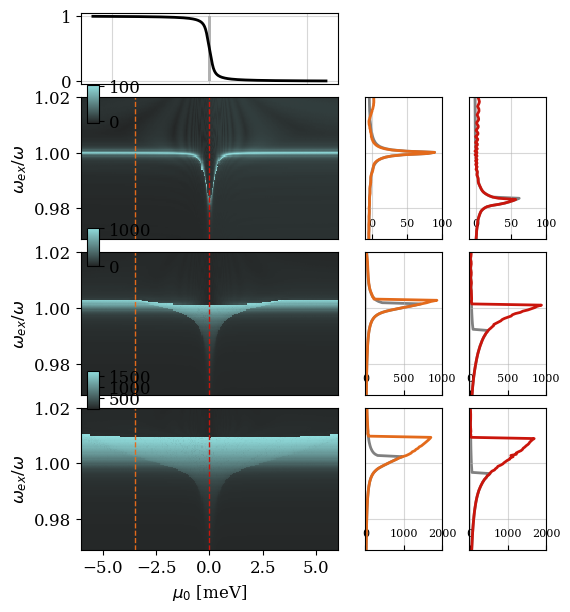

In [ ]:
fig = plt.figure(figsize=(6,11))
gs = fig.add_gridspec(6, 3,wspace=.2,hspace=.1,width_ratios=(1,.3,.3),height_ratios=(.5,1,1,1,1,1))

max_values=[100,1000,2000]
tick_values=[[0,50,100],[0,500,1000],[0,1000,2000]]

freq_max=1.02

cbar_axis=[[.135, .78, 0.02, .035],
           [.135, .65, 0.02, .035],
           [.135, .52, 0.02, .035],]

    
for i,f in zip(range(3),[0.08,0.8,1.6]):
    quantity=np.load('Simulations/Displacement_CNT_theory_F_'+str(f)+'.npz')
    
    if i ==0:
        n = 0.5 + (np.arctan(2*(muR - quantity['mu'])/hGtot_meV) + a*np.arctan(2*(muL - quantity['mu'])/hGtot_meV))/(np.pi*(1 + a))
        ax0=fig.add_subplot(gs[0,0])
        ax0.plot(quantity['mu'],n,color='k',lw=2)
        ax0.tick_params(bottom=False,labelbottom=False)
        ax0.grid(True,zorder=0,alpha=.5)
        ax0.fill_betweenx(x1=-.1,x2=.1,y=n,alpha=.3,color='k',edgecolor=None)

    ax=fig.add_subplot(gs[i+1,0])
    im=ax.pcolormesh(quantity['mu'],quantity['fm'],quantity['displacement_up'],
                 cmap=blue,
                 linewidth=0,rasterized=True)
    ax.set_ylim(quantity['fm'][0],freq_max) 
    
    if i<2: ax.tick_params(bottom=False,labelbottom=False)
    ax.set_ylabel('$\omega_{ex}/\omega$')
    cax_dis=fig.add_axes(cbar_axis[i])
    cbar=fig.colorbar(im, cax = cax_dis, orientation = "vertical")
    
    vertical1=50
    print(quantity['mu'][vertical1])
    ax.plot(np.ones(2)*quantity['mu'][vertical1],list(ax.get_ylim()),'--',lw=1,color='#e36a1bff')
    
    
    vertical2=120
    print(quantity['mu'][vertical2])
    ax.plot(np.ones(2)*quantity['mu'][vertical2],list(ax.get_ylim()),'--',lw=1,color='#ca150cff')
    
    
    ax2=fig.add_subplot(gs[i+1,1])
    ax2.plot(quantity['displacement_up'][:,vertical1],quantity['fm'],lw=2,color='#e36a1bff',zorder=2)
    ax2.plot(quantity['displacement_down'][:,vertical1],quantity['fm'],lw=2,color='grey',zorder=1)
    ax2.set_ylim(quantity['fm'][0],freq_max) 
    ax2.tick_params(left=False,labelleft=False)
    ax2.tick_params(axis="x",direction="in", pad=-15,labelsize=8)
    ax2.grid(True,zorder=0,alpha=.5)
    ax2.set_xlim(-10,max_values[i])
    ax2.set_xticks(ticks=tick_values[i])
    
    ax3=fig.add_subplot(gs[i+1,2])
    ax3.plot(quantity['displacement_up'][:,vertical2],quantity['fm'],lw=2,color='#ca150cff',zorder=2)
    ax3.plot(quantity['displacement_down'][:,vertical2],quantity['fm'],lw=2,color='grey',zorder=1)
    ax3.set_ylim(quantity['fm'][0],freq_max) 
    ax3.tick_params(left=False,labelleft=False)
    ax3.tick_params(axis="x",direction="in", pad=-15,labelsize=8)
    ax3.grid(True,zorder=0,alpha=.5)
    ax3.set_xlim(-10,max_values[i])
    ax3.set_xticks(ticks=tick_values[i])



ax.set_xlabel('$\mu_0$ [meV]')

fig.savefig('Plots/NESS_displacement_Fig2.pdf',transparent=True,pad_inches=0,bbox_inches='tight')

### Theoretical current study (Figure 3)

<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:38: SyntaxWarning: invalid escape sequence '\m'
/var/folders/9g/n4qyr9c55gqbb4trqzwt0x6w0000gn/T/ipykernel_58076/572931985.py:20: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('$\omega_{ex} / \omega$')
/var/folders/9g/n4qyr9c55gqbb4trqzwt0x6w0000gn/T/ipykernel_58076/572931985.py:38: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$\mu_0$ (meV)')


1.3566651556989542
1.3554535243884118
1.3421910025310297


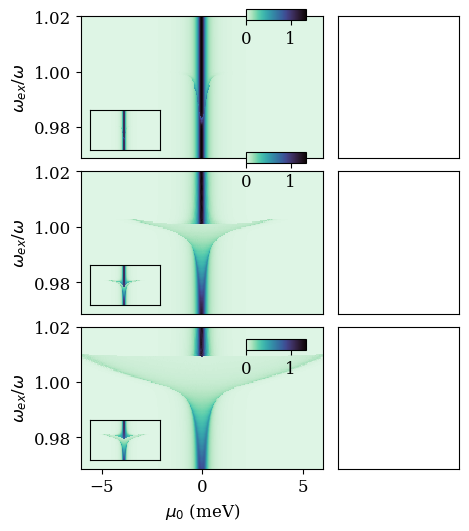

In [6]:
fig = plt.figure(figsize=(6,11))
gs = fig.add_gridspec(6, 3,wspace=.1,hspace=.1,width_ratios=(1,.5,.3),height_ratios=(.5,1,1,1,1,1))


cbar_axis=[[.4, .8, 0.1, .01],
           [.4, .67, 0.1, .01],
           [.4, .5, 0.1, .01],]
    
for i,f in zip(range(3),[0.08,0.8,1.6]):
    quantity=np.load('Simulations/Displacement_CNT_theory_F_'+str(f)+'.npz')

    ax=fig.add_subplot(gs[i+1,0])
    im=ax.pcolor(quantity['mu'],quantity['fm'],quantity['current_up'], ## in e/pi GammaLGammaR/Gammatot
                 cmap=cmapI,
                 vmin=0,vmax=1.35,
                 linewidth=0,rasterized=True)
    print(quantity['current_up'].max())
    
    ax.set_ylim(ax.get_ylim()[0],1.02)
    ax.set_ylabel('$\omega_{ex} / \omega$')
    if i<2: ax.tick_params(bottom=False,labelbottom=False)
    ####
    ax2=fig.add_subplot(gs[i+1,1])
    ax2.tick_params(bottom=False,labelbottom=False,left=False,labelleft=False)
    ###
    ax_ins = inset_axes(ax, width=.7, height=.4, loc="lower left")
    ax_ins.pcolor(quantity['mu'],quantity['fm'],quantity['current_down'], ## in e/pi GammaLGammaR/Gammatot
                 cmap=cmapI,
                 vmin=0,vmax=1.3,
                 linewidth=0,rasterized=True)
    ax_ins.set_ylim(ax_ins.get_ylim()[0],1.02)
    ax_ins.tick_params(bottom=False,labelbottom=False,left=False,labelleft=False)
    
    cax_dis=fig.add_axes(cbar_axis[i])
    cbar=fig.colorbar(im, cax = cax_dis, orientation = "horizontal")


ax.set_xlabel('$\mu_0$ (meV)')
fig.savefig('Plots/NESS_current_Fig3.pdf',transparent=True)

### Theoretical vs experimental comparison (Figure 4)


In [7]:
def Import_data(file):
    '''
    File to import the experimental data
    return:
        fm: driving gfrequency in MHz
        Vg: gate voltage in V
        current: 2-dimentional plot of current in pA
    '''
    Data_landscapes=np.loadtxt('Measurements/'+file, skiprows=5) ## import the files
    Data_landscapes_Vg=np.loadtxt('Measurements/'+file, skiprows=3,max_rows=1) ## in V
    Data=Data_landscapes[1:,:].transpose()*1e12 ## pA
    fm=Data_landscapes[0,:]/1e6 ## MHz
    return fm, Data_landscapes_Vg , Data

experimental_up_names=['MS5_sweepfex-G1-measISDat-45dBm.txt',
                       'MS5_sweepfex-G1-measISDat-35dBm.txt',
                       'MS5_sweepfex-G1-measISDat-20dBm.txt']
experimental_down_names=['MS5_sweepfex-G1-measISDat-45dBm_back.txt',
                         'MS5_sweepfex-G1-measISDat-35dBm_back.txt',
                         'MS5_sweepfex-G1-measISDat-20dBm_back.txt']

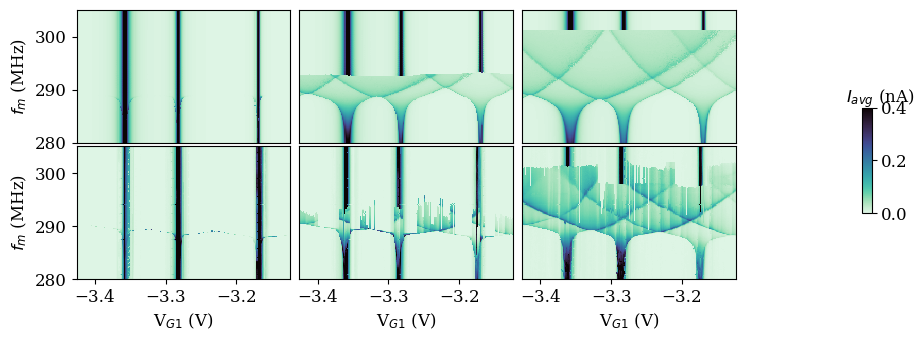

In [8]:
fig = plt.figure(figsize=(10, 3.5))
gs = fig.add_gridspec(4, 4,wspace=0.05,hspace=0.05,width_ratios=(1,1,1,.5))

V_min=-3.38
V_max=-3.25
f_min=285
f_max=293

for i,f in zip(range(3),[0.1,2.0,4.0]):

    # #### simulations plots
    ## import current
    ax=fig.add_subplot(gs[0:2,i])
    quantities_sim=np.load('Simulations/Experimental_simulations_fits_F_'+str(f)+'.npz')
    current_unit=quantities_sim['current_up']*e/np.pi*1e9 ## in nA
    im=ax.pcolor(quantities_sim['Vg'],quantities_sim['fm'],current_unit, 
                cmap=cmapI,vmin=0,vmax=.4,
                 linewidth=0,rasterized=True)
    if i!=0: ax.tick_params(left=False, labelleft=False)
    else: ax.set_ylabel('$f_m$ (MHz)')
    ax.tick_params(bottom=False, labelbottom=False)
    
    ##### experimental plots 
    ax=fig.add_subplot(gs[2:4,i])
    fm, Vg , Data=Import_data(experimental_up_names[i])
    ax.pcolor(Vg,fm,Data/1e3, ## in nA
              cmap=cmapI,vmin=0,vmax=.4,
                 linewidth=0,rasterized=True)
    if i!=0: ax.tick_params(left=False, labelleft=False)
    else: ax.set_ylabel('$f_m$ (MHz)')
    
    ax.set_xlabel(r'V$_{G1}$ (V)')

cax_up=fig.add_axes([.91, 0.3, 0.01, .3])
cbar=fig.colorbar(im, cax = cax_up, orientation = "vertical")
cbar.set_label(r'$I_{avg}$ (nA)',rotation=0, y=1.2,labelpad=-20)


fig.savefig('Plots/NESS_theroy_vs_experiment_Fig4.pdf',transparent=True,pad_inches=0)

### Numerical details for obtaining the NESS (Appendix B)

<>:37: SyntaxWarning: invalid escape sequence '\o'
<>:37: SyntaxWarning: invalid escape sequence '\o'
/var/folders/9g/n4qyr9c55gqbb4trqzwt0x6w0000gn/T/ipykernel_58076/817980742.py:37: SyntaxWarning: invalid escape sequence '\o'
  ax0.set_xlabel('t$\omega/\pi$')


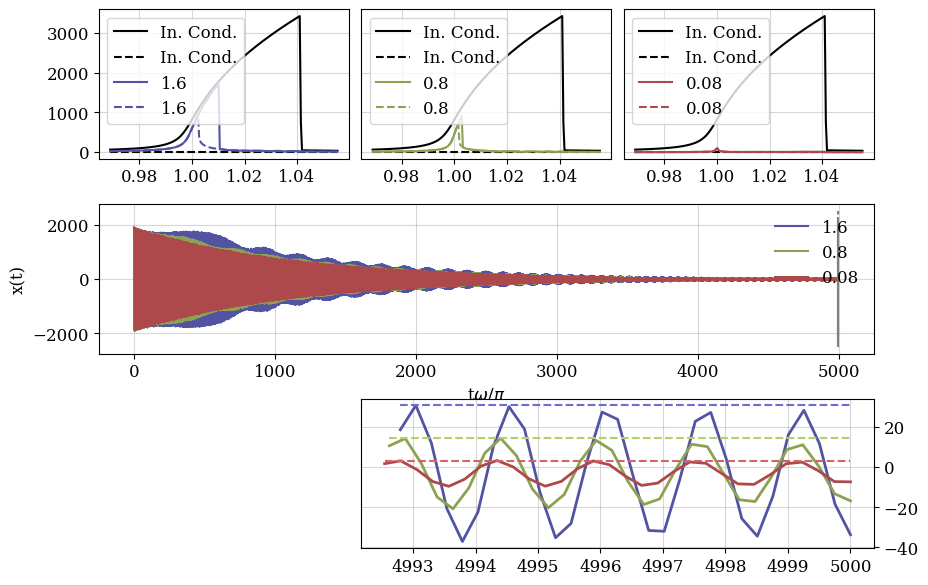

In [9]:
fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(3, 3,wspace=0.05,hspace=0.3)
ax0= fig.add_subplot(gs[1,:])
ax= fig.add_subplot(gs[2,1:])

names_up=['F1.6_up','F0.8_up','F0.08_up']
names_down=['F1.6_down','F0.8_down','F0.08_down']

cmap = plt.colormaps["tab20b"]
color_num=[1,5,13]

for i,f in zip(range(3),[1.6,0.8,0.08]):
    quantity=np.load('Simulations/time_dynamics_displacement_backaction_'+str(f)+'.npz')
    length_=len(quantity['displacement_up'])
    t= np.linspace (0, 5000, length_)
    ax0.plot(t,quantity['displacement_up'],color=cmap([color_num[i]]),label=str(f))
    ax0.plot(np.ones(2)*t[length_-30],list(ax0.get_ylim()),'--',color='grey')
    
    ax.plot(t[length_-30:],quantity['displacement_up'][length_-30:],color=cmap([color_num[i]]),lw=2)
    ax.plot(t[length_-30:],np.ones(30)*np.max(quantity['displacement_up'][length_-30:]),'--',color=cmap([color_num[i]+1]))

    quantity2=np.load('Simulations/Example_initial_cond.npz')
    ax1= fig.add_subplot(gs[0,i])
    ax1.plot(quantity2['freq'],quantity2['Initial_cond'],color='k',label='In. Cond.')
    ax1.plot(quantity2['freq'],np.zeros(len(quantity2['freq'])),'--',color='k',label='In. Cond.')
    ax1.plot(quantity2['freq'],quantity2[names_up[i]],color=cmap([color_num[i]]),label=str(f))
    ax1.plot(quantity2['freq'],quantity2[names_down[i]],'--',color=cmap([color_num[i]]),label=str(f))
    if i!=0: ax1.tick_params(left=False, labelleft=False)
    ax1.legend()
    ax1.grid(True,zorder=0,alpha=.5)

    
ax0.grid(True,zorder=0,alpha=.5)
ax.grid(True,zorder=0,alpha=.5)
ax0.legend(frameon=False,loc='upper right')

ax0.set_xlabel('t$\omega/\pi$')
ax0.set_ylabel('x(t)')

ax.yaxis.tick_right()


fig.savefig('Plots/Numerical_details_Fig5.pdf',transparent=True,pad_inches=0,bbox_inches='tight')

### Displacement plots corresponding to Fig. 9 (Appendix E)

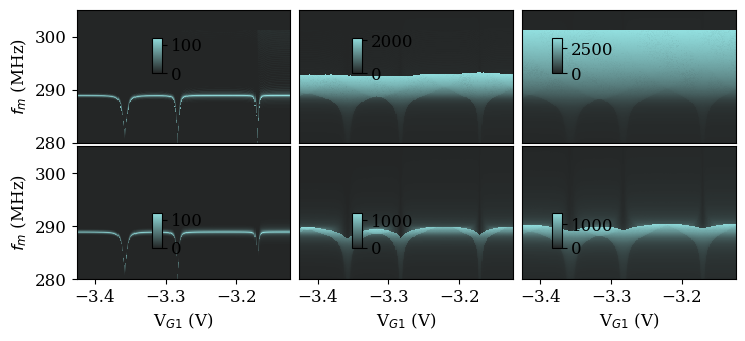

In [13]:
fig = plt.figure(figsize=(10, 3.5))
gs = fig.add_gridspec(4, 4,wspace=0.05,hspace=0.05,width_ratios=(1,1,1,.5))
cax_=[[.2, 0.7, 0.01, .1], [.4, 0.7, 0.01, .1],[.6, 0.7, 0.01, .1], 
      [.2, 0.2, 0.01, .1], [.4, 0.2, 0.01, .1],[.6, 0.2, 0.01, .1], ]

for i,f in zip(range(3),[0.1,2.0,4.0]):
    
    ax=fig.add_subplot(gs[0:2,i])
    ## import displacement
    quantities_sim=np.load('Simulations/Experimental_simulations_fits_F_'+str(f)+'.npz')
    
    #### simulations plots -- up displacement
    im=ax.pcolor(quantities_sim['Vg'],quantities_sim['fm'],quantities_sim['displacement_up'], 
                 cmap=blue,
                 vmin=0,
                 linewidth=0,rasterized=True,zorder=0)
    if i!=0: ax.tick_params(left=False, labelleft=False)
    else: ax.set_ylabel('$f_m$ (MHz)')
    ax.tick_params(bottom=False, labelbottom=False)
    cbar=fig.colorbar(im, cax = fig.add_axes(cax_[i]), orientation = "vertical")
    
    ##### simulations plots -- down displacement
    ax=fig.add_subplot(gs[2:4,i])
    im=ax.pcolor(quantities_sim['Vg'],quantities_sim['fm'],quantities_sim['displacement_down'], 
                 cmap=blue,
                 vmin=0,
                 linewidth=0,rasterized=True)
    
    if i!=0: ax.tick_params(left=False, labelleft=False)
    else: ax.set_ylabel('$f_m$ (MHz)')
    ax.set_xlabel(r'V$_{G1}$ (V)')
    cbar=fig.colorbar(im, cax = fig.add_axes(cax_[i+3]), orientation = "vertical")

fig.savefig('Plots/NESS_theroy_vs_experiment_displacment_Fig9.pdf',transparent=True,pad_inches=0)

### Experimental plots with frequency swept from high to low values (Fig. 10 in Appendix F)

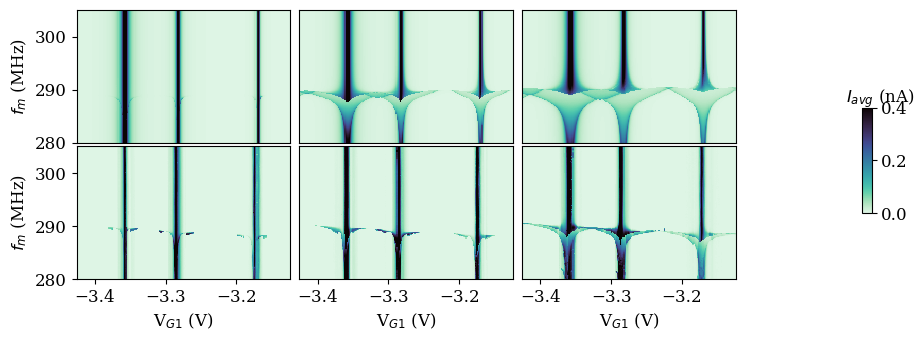

In [11]:
fig = plt.figure(figsize=(10, 3.5))
gs = fig.add_gridspec(4, 4,wspace=0.05,hspace=0.05,width_ratios=(1,1,1,.5))


for i,f in zip(range(3),[0.1,2.0,4.0]):
    
    ax=fig.add_subplot(gs[0:2,i])
    ### import current
    quantities_sim=np.load('Simulations/Experimental_simulations_fits_F_'+str(f)+'.npz')
    
    #### simulations plots
    current_unit=quantities_sim['current_down']*e/np.pi*1e9 ## in nA
    im=ax.pcolor(quantities_sim['Vg'],quantities_sim['fm'],current_unit,
              cmap=cmapI,vmin=0,vmax=.4,
                 linewidth=0,rasterized=True)
    if i!=0: ax.tick_params(left=False, labelleft=False)
    else: ax.set_ylabel('$f_m$ (MHz)')
    ax.tick_params(bottom=False, labelbottom=False)
    
    ##### experimental plots 
    ax=fig.add_subplot(gs[2:4,i])
    fm, Vg , Data=Import_data(experimental_down_names[i])
    ax.pcolor(Vg,fm,Data/1e3, ## in nA
              cmap=cmapI,vmin=0,vmax=.4,
                 linewidth=0,rasterized=True)
    if i!=0: ax.tick_params(left=False, labelleft=False)
    else: ax.set_ylabel('$f_m$ (MHz)')
    ax.set_xlabel(r'V$_{G1}$ (V)')

cax_up=fig.add_axes([.91, 0.3, 0.01, .3])
cbar=fig.colorbar(im, cax = cax_up, orientation = "vertical")
cbar.set_label(r'$I_{avg}$ (nA)',rotation=0, y=1.2,labelpad=-20)

fig.savefig('Plots/NESS_theroy_vs_experiment_down_sweep_Fig10.pdf',transparent=True,pad_inches=0)